<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC - PAIR VARIABLES</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.  
Here we focus in the distribution and possible cuts of the pair variables.  
In this particular version of this notebook, we start by uploading a dataframe where the mother hypothesis (D0, anti-D0 or 'both') have already been computed in a column. 

The codes in the pdg for the important particles are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>

#### WE UPLOAD A DATAFRAME WITH ALREADY PRESENT MOTHER HYPOTHESIS

In [2]:
final_results = pd.read_pickle("/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs_concatenated/ALL_MC_only_couple_with_BKG.pkl")

In [3]:
final_results.columns

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'mother_pdg_pos', 'truth', 'same_mother', 'mother_hyp'],
      dtype='object')

Here:
* 'same_mother' is a boolean value that tells us if the two tracks in a row come from the same mother
* 'mother_pdg_pos' is the pdg code of the mother of the positive particle

### TRUE SIGNAL COUNT AFTER SINGLE TRACKS CUTS

Redefining true maks (cause we applied cuts):

In [4]:
print("======== STATISTICS FOR PAIR DATAFRAME AFTER SINGLE TRACKS CUTS AND MOTHER HYPOTHESIS ========= \n")

print(f"Length of dataframe: {len(final_results):_} rows\n")

# MOTHER HYPOTHESIS
mask_d0_hyp         = (final_results["mother_hyp"] == "D0")
mask_anti_d0_hyp    = (final_results["mother_hyp"] == "Anti-D0")
mask_both_hyp       = (final_results["mother_hyp"] == "BothSignal")
d0_hyp_tot       =   mask_d0_hyp.sum()
anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
both_hyp_tot     =   mask_both_hyp.sum()
print("MOTHER HYPOTHESIS COUNTS:")
print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")

# TRUE SIGNAL
# I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
mask_true_d0  = (mask_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == 1 )
# I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
mask_true_anti_d0    =  (mask_anti_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == -1 )
mask_signal = (mask_true_d0 | mask_true_anti_d0)
mask_background = ( ~mask_signal )
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("TRUE SIGNAL COUNTS:")
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of signal particles: ", signal_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

======== STATISTICS FOR PAIR DATAFRAME AFTER SINGLE TRACKS CUTS AND MOTHER HYPOTHESIS ========= 

Length of dataframe: 52_608_601 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               9_693_226
Number of hypothetic Anti-D0:          10_018_155
Number of double hypothesis particles: 32_897_220
Total hypothetic signal:               85_505_821 

TRUE SIGNAL COUNTS:
Number of D0:       11611
Number of anti-D0:  12159
Number of signal particles:  23770
Number of background pairs: 52_584_831
Fraction of D0 and anti-D0 over total: 0.0452%


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 52_608_601 rows and 10 columns.
It occupies 5_516.59 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,mother_pdg_pos,truth,same_mother,mother_hyp
0,-0.000008,1.803016,1.778223,1.575074,0.004660,0.995067,0.0,0,True,BothSignal
1,0.000008,2.215073,2.207963,0.473187,0.013202,0.053475,0.0,0,True,BothSignal
4,-0.000006,1.802861,1.811291,1.872615,0.004316,-0.990615,0.0,0,True,Anti-D0
5,0.000006,0.753274,0.809453,2.512969,0.010321,-0.959486,0.0,0,True,Anti-D0
6,0.000005,1.906000,1.813098,0.518201,0.029233,-0.969578,0.0,0,True,Anti-D0
71693460,-0.000007,0.817484,0.819815,1.942073,0.027600,-0.992015,0.0,0,True,D0
71693461,-0.000029,1.276946,1.442003,0.654153,0.484136,0.599167,0.0,0,True,D0
71693462,0.000004,2.277966,2.295974,0.220301,0.159155,-0.915865,0.0,0,True,BothSignal
71693463,-0.001381,0.990568,0.992497,0.324600,0.118799,-0.578420,0.0,0,True,BothSignal
71693464,0.000200,1.194881,1.045351,0.706488,0.026848,-0.106647,0.0,0,True,Anti-D0


---

---

---

<center><span style="font-size:35px;"><b>PAIR VARIABLES DISTRIBUTION</b></span></center>

### $p_T$ DISTRIBUTION

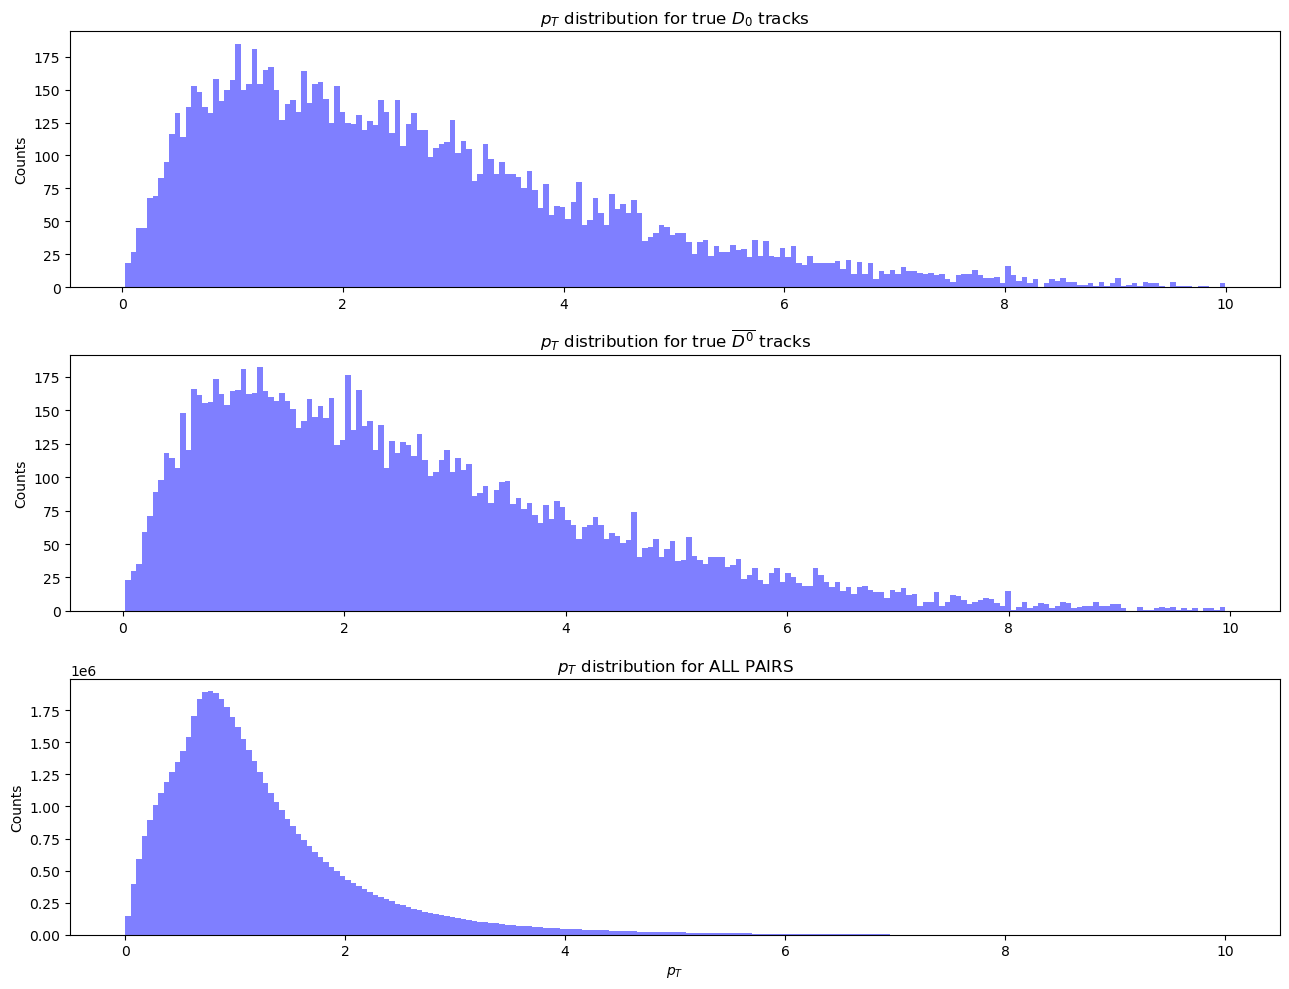

In [6]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$, $[3-6]$ or $[3-8]$ could be useful to find the signal.

## DEFINING $p_t$ WINDOWS
We want now to create the masks for the various $p_t$ slices, in order to better see the signal for each $p_t$ interval: 0-1.5,1.5-3,3-8,8-16.  
Watch out: now $p_t$ is the transverse momentum of the mother particle, not of the single track!

In [7]:
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1.5), 
    final_results["pt"].between(1.5, 3),
    final_results["pt"].between(3, 16)
]

pt_windows = [ "0-1.5", "1.5-3", "3-16" ]

# let's count signal and background for each pT window
signal_tot_per_pt = []
num_bg_pairs_per_pt = []

for mask_pt in multiple_masks_pt:

    # count signal for each pT window
    signal_tot_i = len(final_results.loc[mask_signal & mask_pt, "truth"])
    signal_tot_per_pt.append(signal_tot_i)

    # count background for each pT window
    bg_tot = len(final_results.loc[mask_background & mask_pt, "truth"])
    num_bg_pairs_per_pt.append(bg_tot)

In [8]:
# debug:
signal_tot_per_pt

[7553, 7886, 8331]

In [9]:
# debug:
num_bg_pairs_per_pt

[38613914, 11404304, 2566618]

### APPLYING PAIR VARIABLES CUTS

In [10]:
# let's define the cuts for each pt window:
cuts_config = [
    # pt ∈ [0, 1.5]
    dict(
        cos_pointing = 0.5636
        # no dca product cut here
        # no decay_length cut here
    ),
    
    # pt ∈ [1.5, 3]
    dict(
        cos_pointing = 0.7934,
        dcaXY_product = -2.068e-05
        # no decay_length cut here
    ),
    
    # pt ∈ [3, 16]
    dict(
        cos_pointing = 0.9835,
        dcaXY_product = -1.746e-05,
        decay_length = 0.0069
    )
]

In [11]:
# build pt-dependent cuts
cuts_per_pt = []

for pt_mask, cfg in zip(multiple_masks_pt, cuts_config):

    cut = pt_mask.copy()

    if "cos_pointing" in cfg:
        cut &= final_results["cos_pointing"] > cfg["cos_pointing"]
    if "dcaXY_product" in cfg:
        cut &= final_results["dcaXY_product"] < cfg["dcaXY_product"]
    if "decay_length" in cfg:
        cut &= final_results["decay_length"] > cfg["decay_length"]

    cuts_per_pt.append(cut)

# let's make a big OR over cuts:
cuts = cuts_per_pt[0]
for cut_pt in cuts_per_pt[1:]: cuts = cuts | cut_pt

In [12]:
# final cutted dataframe
final_results = final_results[cuts]

In [13]:
print("======== STATISTICS FOR PAIR DATAFRAME AFTER PAIR TRACKS CUTS ========= \n")

print(f"Length of dataframe: {len(final_results):_} rows\n")

# MOTHER HYPOTHESIS
mask_d0_hyp         = (final_results["mother_hyp"] == "D0")
mask_anti_d0_hyp    = (final_results["mother_hyp"] == "Anti-D0")
mask_both_hyp       = (final_results["mother_hyp"] == "BothSignal")
d0_hyp_tot       =   mask_d0_hyp.sum()
anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
both_hyp_tot     =   mask_both_hyp.sum()
print("MOTHER HYPOTHESIS COUNTS:")
print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")

# ---------- let's redefine the masks for the MC info on TRUE D0 and anti-D0 ------
# I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
mask_true_d0_after = ( mask_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == 1 )
# I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
mask_true_anti_d0_after = ( mask_anti_d0_hyp | mask_both_hyp ) & ( final_results["truth"] == -1 )
mask_signal_after = ( (mask_true_d0_after) | (mask_true_anti_d0_after) )
mask_background_after = ( ~mask_signal_after )

d0_tot_after = np.sum( mask_true_d0_after )
anti_d0_tot_after = np.sum( mask_true_anti_d0_after )
signal_tot_after = d0_tot_after + anti_d0_tot_after
num_bg_pairs_after = np.sum( mask_background_after )
print("TRUE SIGNAL COUNTS:")
print("Number of D0:      ", d0_tot_after )
print("Number of anti-D0: ", anti_d0_tot_after )
print(f"Number of signal particles: ", signal_tot_after )
print(f"Number of background pairs: {num_bg_pairs_after:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot_after+anti_d0_tot_after)/len(final_results) * 100:.4f}%"  )

======== STATISTICS FOR PAIR DATAFRAME AFTER PAIR TRACKS CUTS ========= 

Length of dataframe: 11_263_347 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               1_874_697
Number of hypothetic Anti-D0:          1_915_959
Number of double hypothesis particles: 7_472_691
Total hypothetic signal:               18_736_038 

TRUE SIGNAL COUNTS:
Number of D0:       4811
Number of anti-D0:  5229
Number of signal particles:  10040
Number of background pairs: 11_253_307
Fraction of D0 and anti-D0 over total: 0.0891%


### $p_T$ distribution after cuts

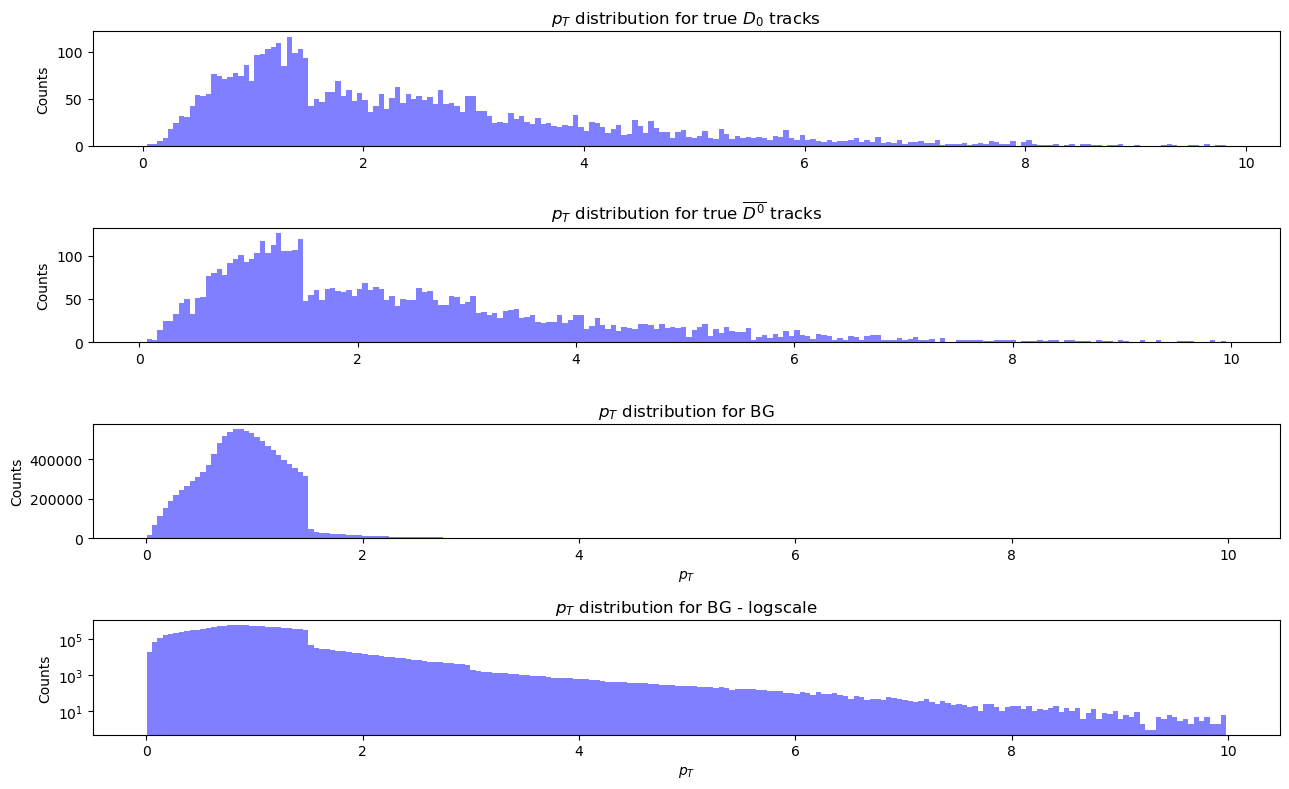

In [14]:
N_BINS = 200
fig, axs = plt.subplots(4, 1, figsize=(13, 8))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0_after, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0_after, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results.loc[mask_background_after, 'pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for BG")

# --- pT FOR ALL PAIRS - logscale ---
data = final_results.loc[mask_background_after, 'pt'].values
data = data[data < 10]
axs[3].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[3].set_xlabel("$p_T$")
axs[3].set_ylabel("Counts")
axs[3].set_title("$p_T$ distribution for BG - logscale")
axs[3].set_yscale("log")

plt.tight_layout()
plt.show()
del data

It's evident that we found good cuts in the $p_T$ windows $[1.5-3]$ and $[3-16]$, while in $[0-1.5]$ it was too hard.

In [15]:
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1.5), 
    final_results["pt"].between(1.5, 3),
    final_results["pt"].between(3, 16)
]
pt_windows = [ "0-1.5", "1.5-3", "3-16" ]

print("Number of data lasted on each $p_T$ window:\n")

for i, mask_pt in enumerate(multiple_masks_pt):
    # count signal for each pT window
    signal_tot_i = np.sum( mask_signal_after & mask_pt )
    # count background for each pT window
    bg_tot = np.sum( mask_background_after & mask_pt )

    print(
        f"pT window {pt_windows[i]}: "
        f"Signal = {signal_tot_i}, "
        f"Background = {bg_tot:_}, "
        f"Total = {signal_tot_i + bg_tot:_}"
    )

Number of data lasted on each $p_T$ window:

pT window 0-1.5: Signal = 4064, Background = 10_828_330, Total = 10_832_394
pT window 1.5-3: Signal = 3195, Background = 390_155, Total = 393_350
pT window 3-16: Signal = 2781, Background = 34_824, Total = 37_605


---

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS FIT</b></span></center>

### LET'S FOCUS ON each $p_T$ window

```python
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1.5), 
    final_results["pt"].between(1.5, 3),
    final_results["pt"].between(3, 16)
]
pt_windows = [ "0-1.5", "1.5-3", "3-16" ]

for i, mask_pt in enumerate(multiple_masks_pt):

======== STATISTICS FOR PAIR DATAFRAME of the pT window 0-1.5 ========= 

Length of dataframe: 10_832_394 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               1_765_080
Number of hypothetic Anti-D0:          1_802_424
Number of double hypothesis particles: 7_264_890
Total hypothetic signal:               18_097_284 

TRUE SIGNAL COUNTS:
Number of D0:       1934
Number of anti-D0:  2130
Number of signal particles:  4064
Number of background pairs: 10_828_330
Fraction of signal over total: 0.0375%
TRUE D0 CLASSIFICATION:
Number of D0 classified as D0:       1_632
Number of D0 classified as anti-D0:  29  (these are not kept in our true masks)
Number of D0 classified as 'both':   302

TRUE ANTI-D0 CLASSIFICATION:
Number of anti-D0 classified as D0:       22 (these are not kept in our true masks)
Number of anti-D0 classified as anti-D0:  1_809
Number of anti-D0 classified as 'both':   321

REFLEX CLASSIFICATION:
Number of reflex by wrong classified D0:        29
Number of 

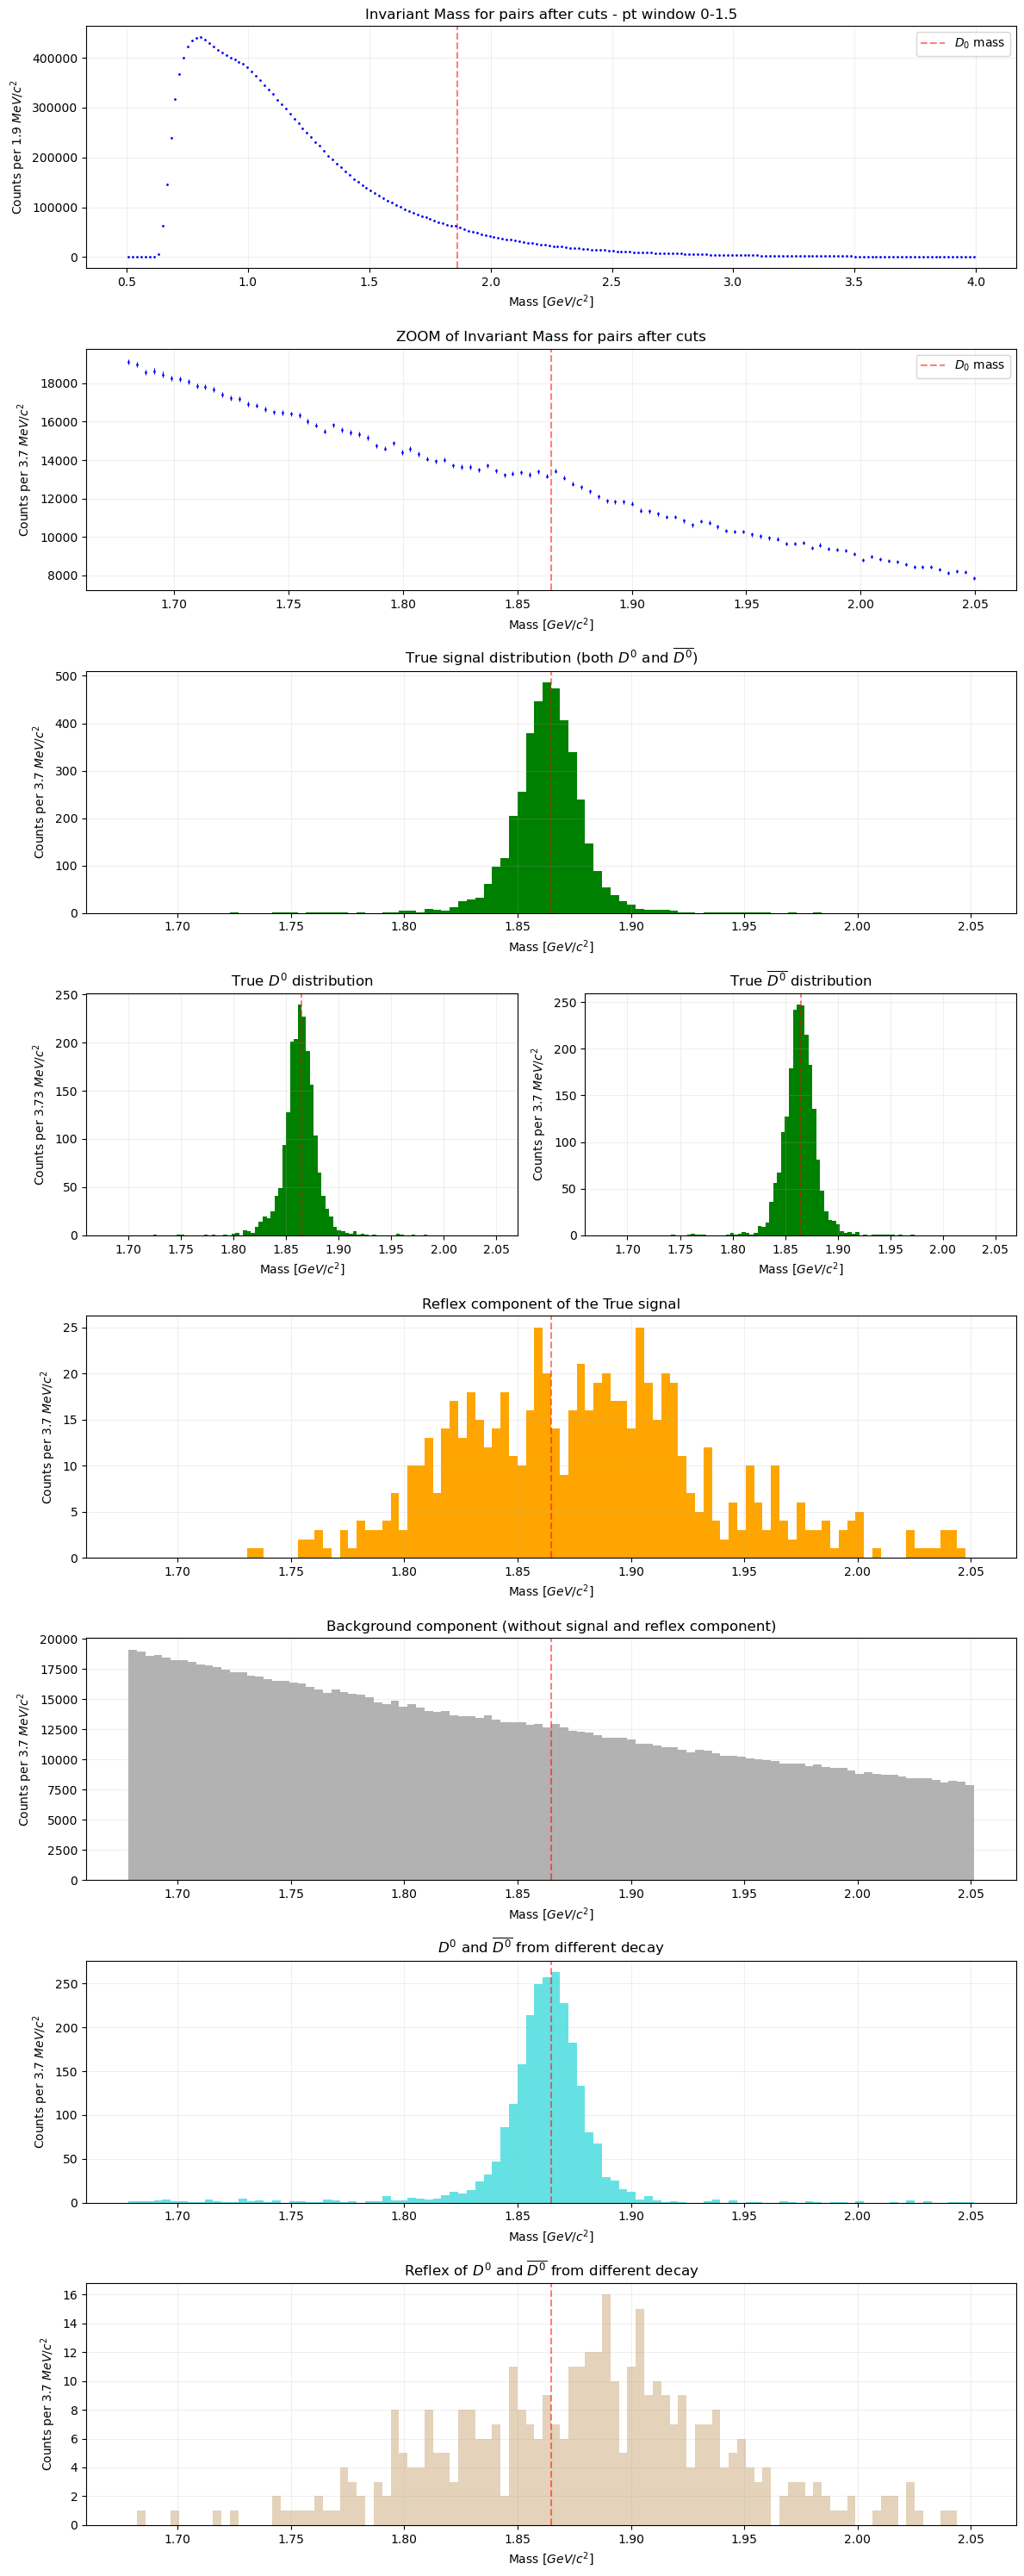

Let's confront signal before and after cuts + zoom in pt slice:

Total D0 before cuts:               11611
Total D0 found after cuts:          1934 ---> 16.66%

Total anti-D0 before cuts:          12159
Total anti-D0 found after cuts:     2130 ---> 17.52%

Total signal before cuts:           23770
Total signal found after cuts:      4064 ---> 17.10%

Total background found after cuts:  ---> 20.59%

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):

Signal found in the interval:     3985
Background found in the interval: 420483

Signal fraction in interval:     0.94%
Significance (S/√(S+B)):          6.12
Ratio (S/B):                      0.01


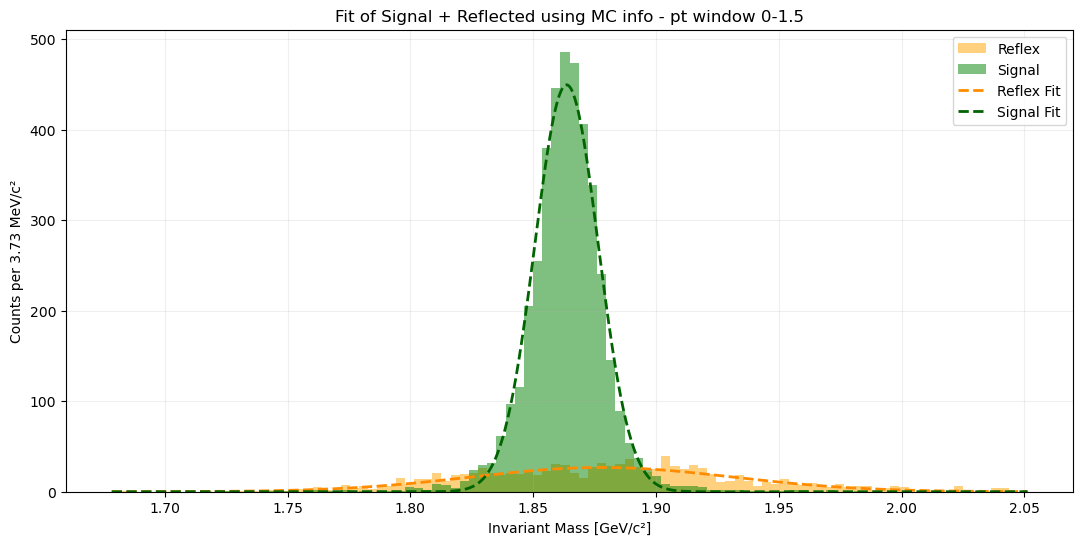


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8636       0.0129       14.575
Reflex             1.8779       0.0532        3.570 

Ratio N1/N2 (reflex/signal):                  0.245 


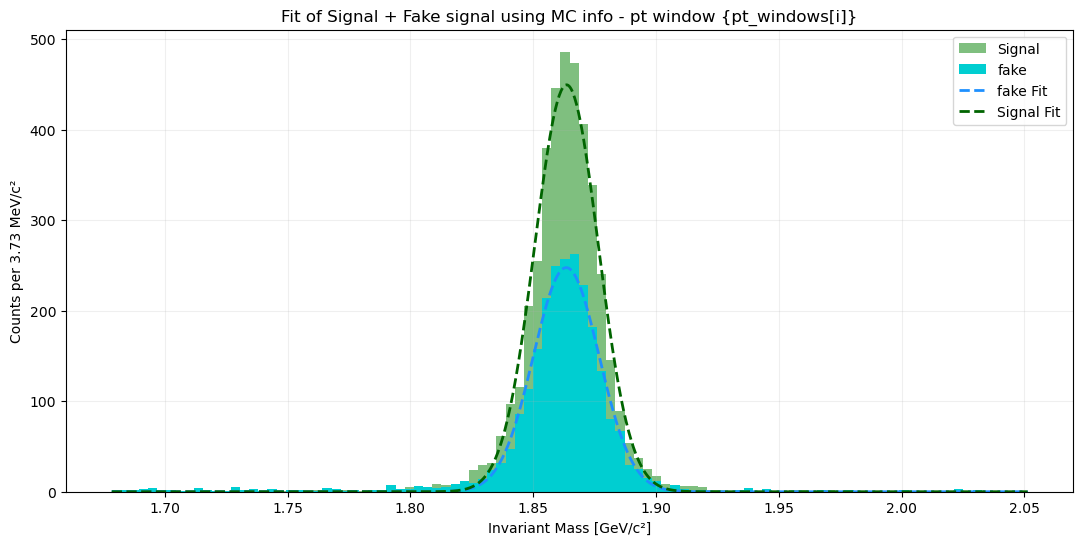


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8636       0.0129       14.575
fake               1.8635       0.0134        8.292 

Ratio N3/N2 (fake/signal):                  0.569 


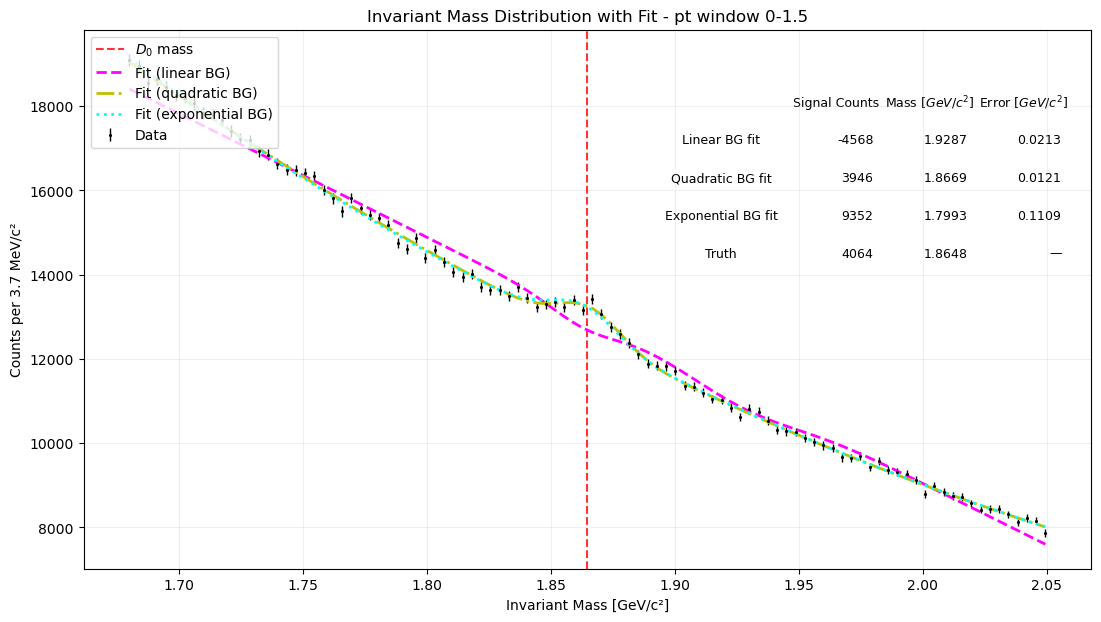


================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear            -4568     1.928662     0.021319
Quadratic          3946     1.866909     0.012090
Exponential        9352     1.799281     0.110851
truth              4064     1.864840


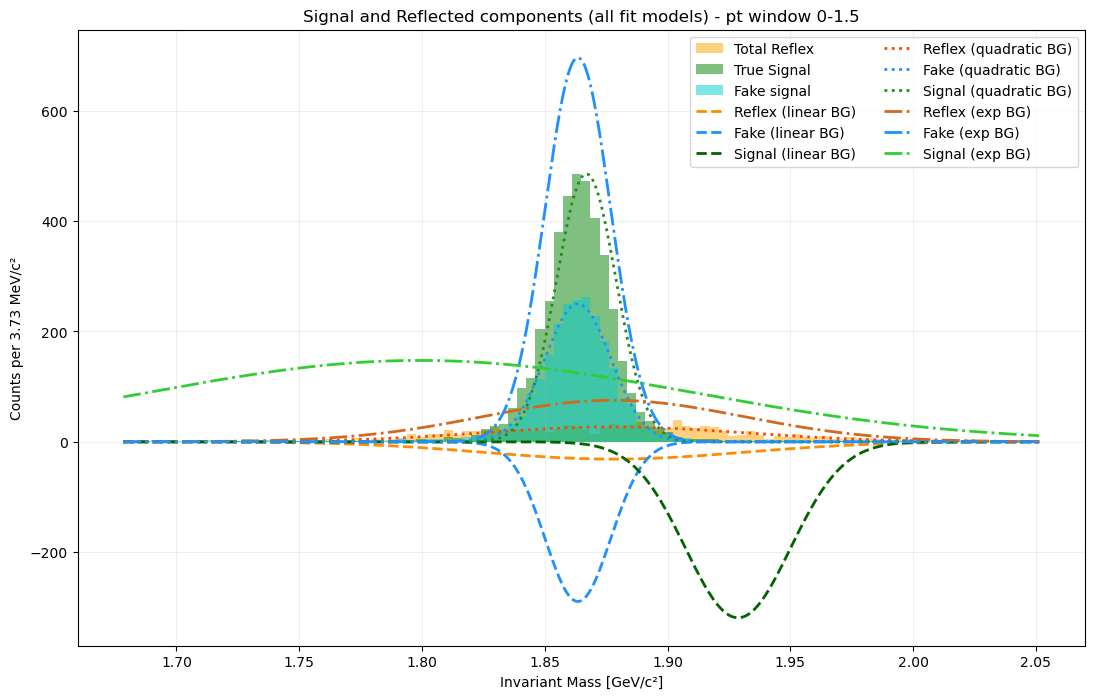

======== STATISTICS FOR PAIR DATAFRAME of the pT window 1.5-3 ========= 

Length of dataframe: 393_350 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               98_905
Number of hypothetic Anti-D0:          102_372
Number of double hypothesis particles: 192_073
Total hypothetic signal:               585_423 

TRUE SIGNAL COUNTS:
Number of D0:       1544
Number of anti-D0:  1651
Number of signal particles:  3195
Number of background pairs: 390_155
Fraction of signal over total: 0.8123%
TRUE D0 CLASSIFICATION:
Number of D0 classified as D0:       1_212
Number of D0 classified as anti-D0:  31  (these are not kept in our true masks)
Number of D0 classified as 'both':   332

TRUE ANTI-D0 CLASSIFICATION:
Number of anti-D0 classified as D0:       38 (these are not kept in our true masks)
Number of anti-D0 classified as anti-D0:  1_306
Number of anti-D0 classified as 'both':   345

REFLEX CLASSIFICATION:
Number of reflex by wrong classified D0:        31
Number of reflex by wrong 

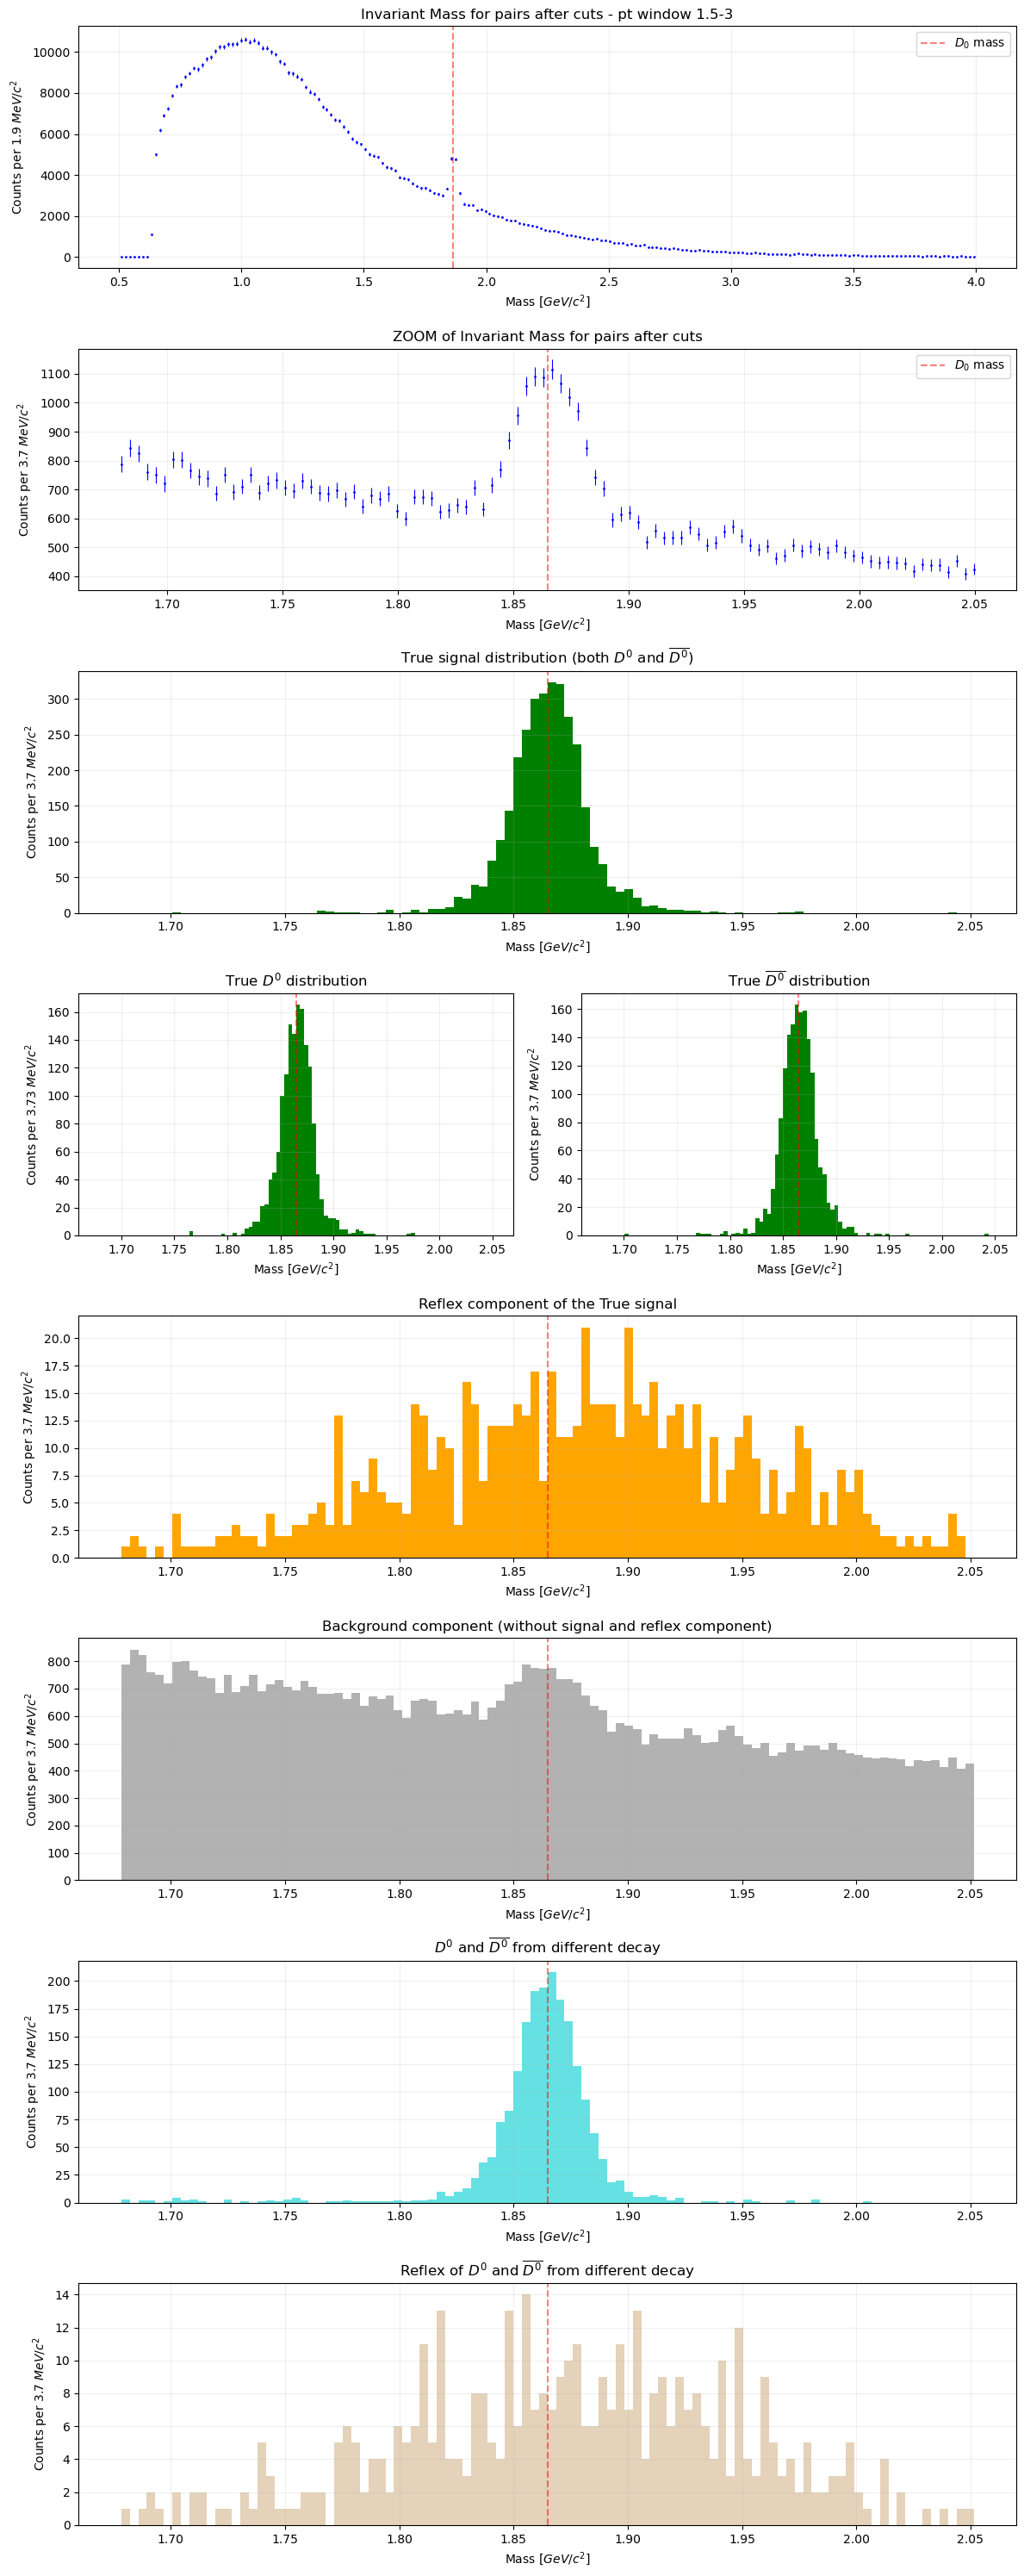

Let's confront signal before and after cuts + zoom in pt slice:

Total D0 before cuts:               11611
Total D0 found after cuts:          1544 ---> 13.30%

Total anti-D0 before cuts:          12159
Total anti-D0 found after cuts:     1651 ---> 13.58%

Total signal before cuts:           23770
Total signal found after cuts:      3195 ---> 13.44%

Total background found after cuts:  ---> 0.74%

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):

Signal found in the interval:     3122
Background found in the interval: 21295

Signal fraction in interval:     12.79%
Significance (S/√(S+B)):          19.98
Ratio (S/B):                      0.15


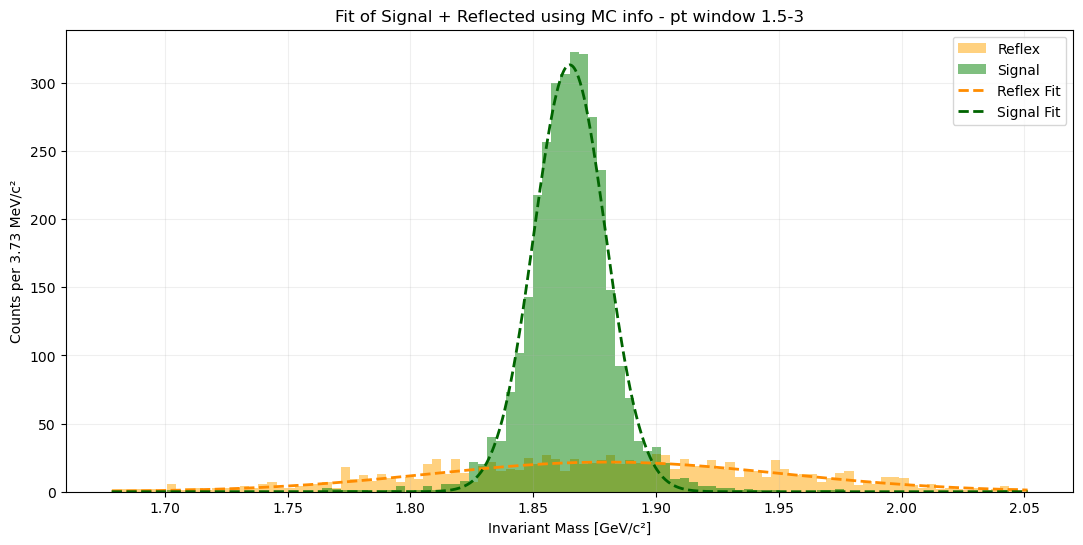


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8649       0.0146       11.448
Reflex             1.8801       0.0717        3.909 

Ratio N1/N2 (reflex/signal):                  0.341 


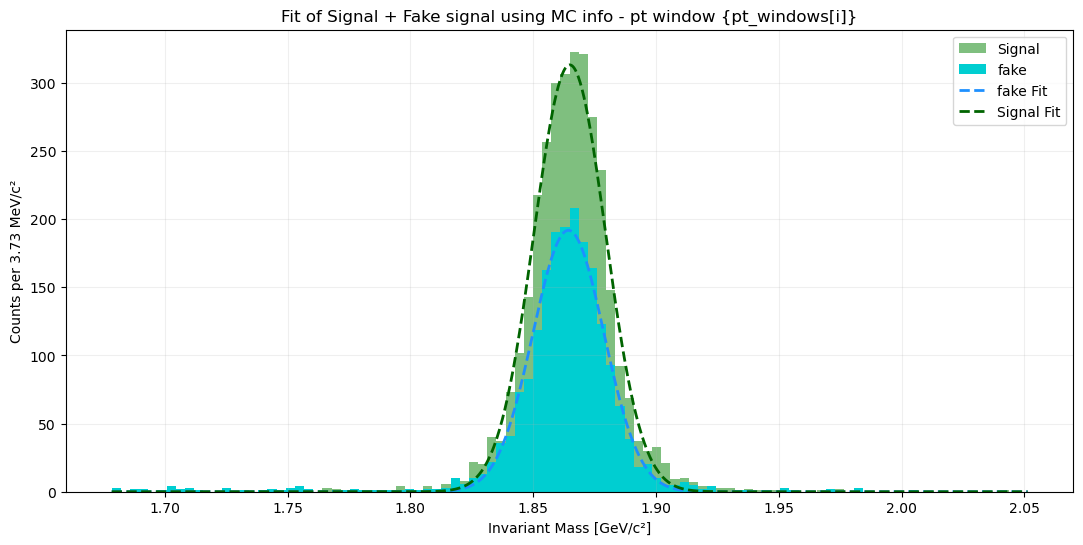


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8649       0.0146       11.448
fake               1.8643       0.0144        6.950 

Ratio N3/N2 (fake/signal):                  0.607 


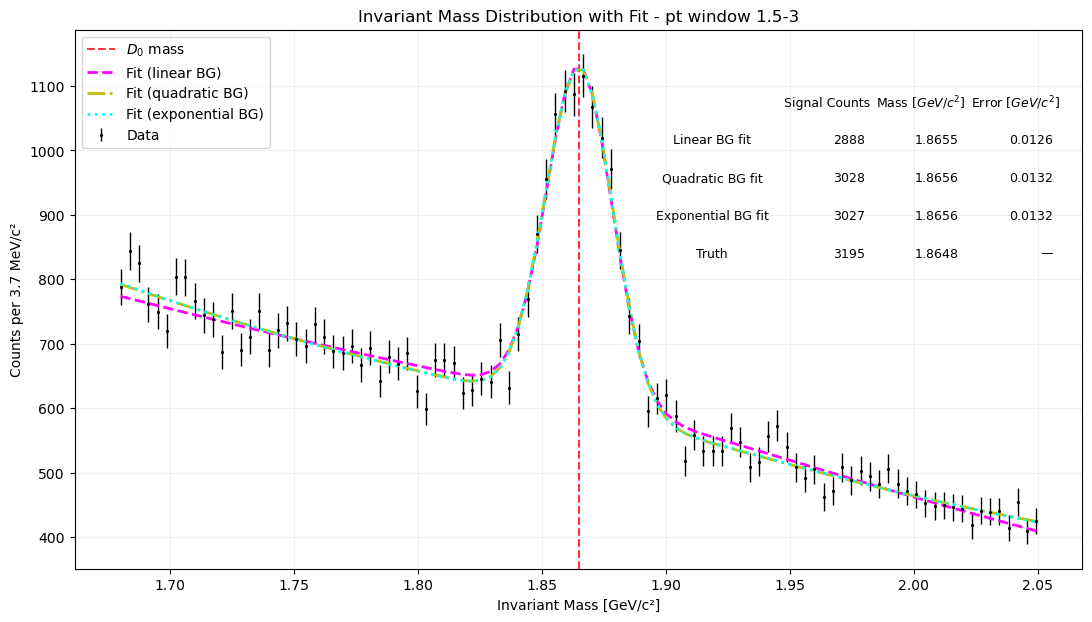


================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear             2888     1.865541     0.012603
Quadratic          3028     1.865598     0.013160
Exponential        3027     1.865582     0.013156
truth              3195     1.864840


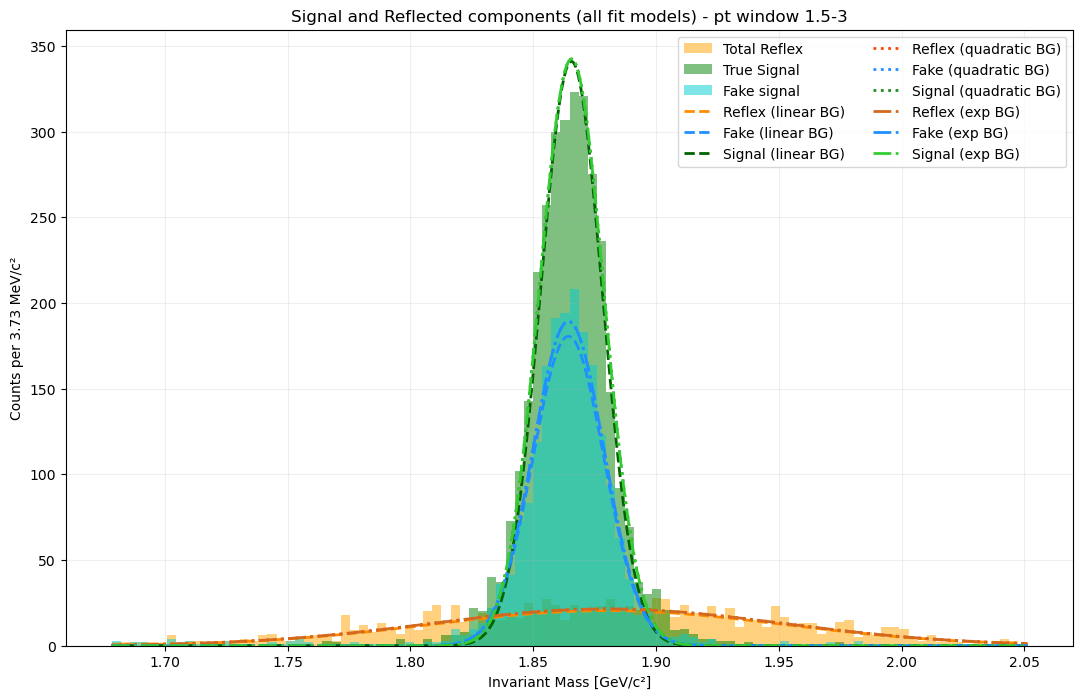

======== STATISTICS FOR PAIR DATAFRAME of the pT window 3-16 ========= 

Length of dataframe: 37_605 rows

MOTHER HYPOTHESIS COUNTS:
Number of hypothetic D0:               10_712
Number of hypothetic Anti-D0:          11_164
Number of double hypothesis particles: 15_729
Total hypothetic signal:               53_334 

TRUE SIGNAL COUNTS:
Number of D0:       1333
Number of anti-D0:  1448
Number of signal particles:  2781
Number of background pairs: 34_824
Fraction of signal over total: 7.3953%
TRUE D0 CLASSIFICATION:
Number of D0 classified as D0:       1_061
Number of D0 classified as anti-D0:  31  (these are not kept in our true masks)
Number of D0 classified as 'both':   272

TRUE ANTI-D0 CLASSIFICATION:
Number of anti-D0 classified as D0:       36 (these are not kept in our true masks)
Number of anti-D0 classified as anti-D0:  1_146
Number of anti-D0 classified as 'both':   302

REFLEX CLASSIFICATION:
Number of reflex by wrong classified D0:        31
Number of reflex by wrong classi

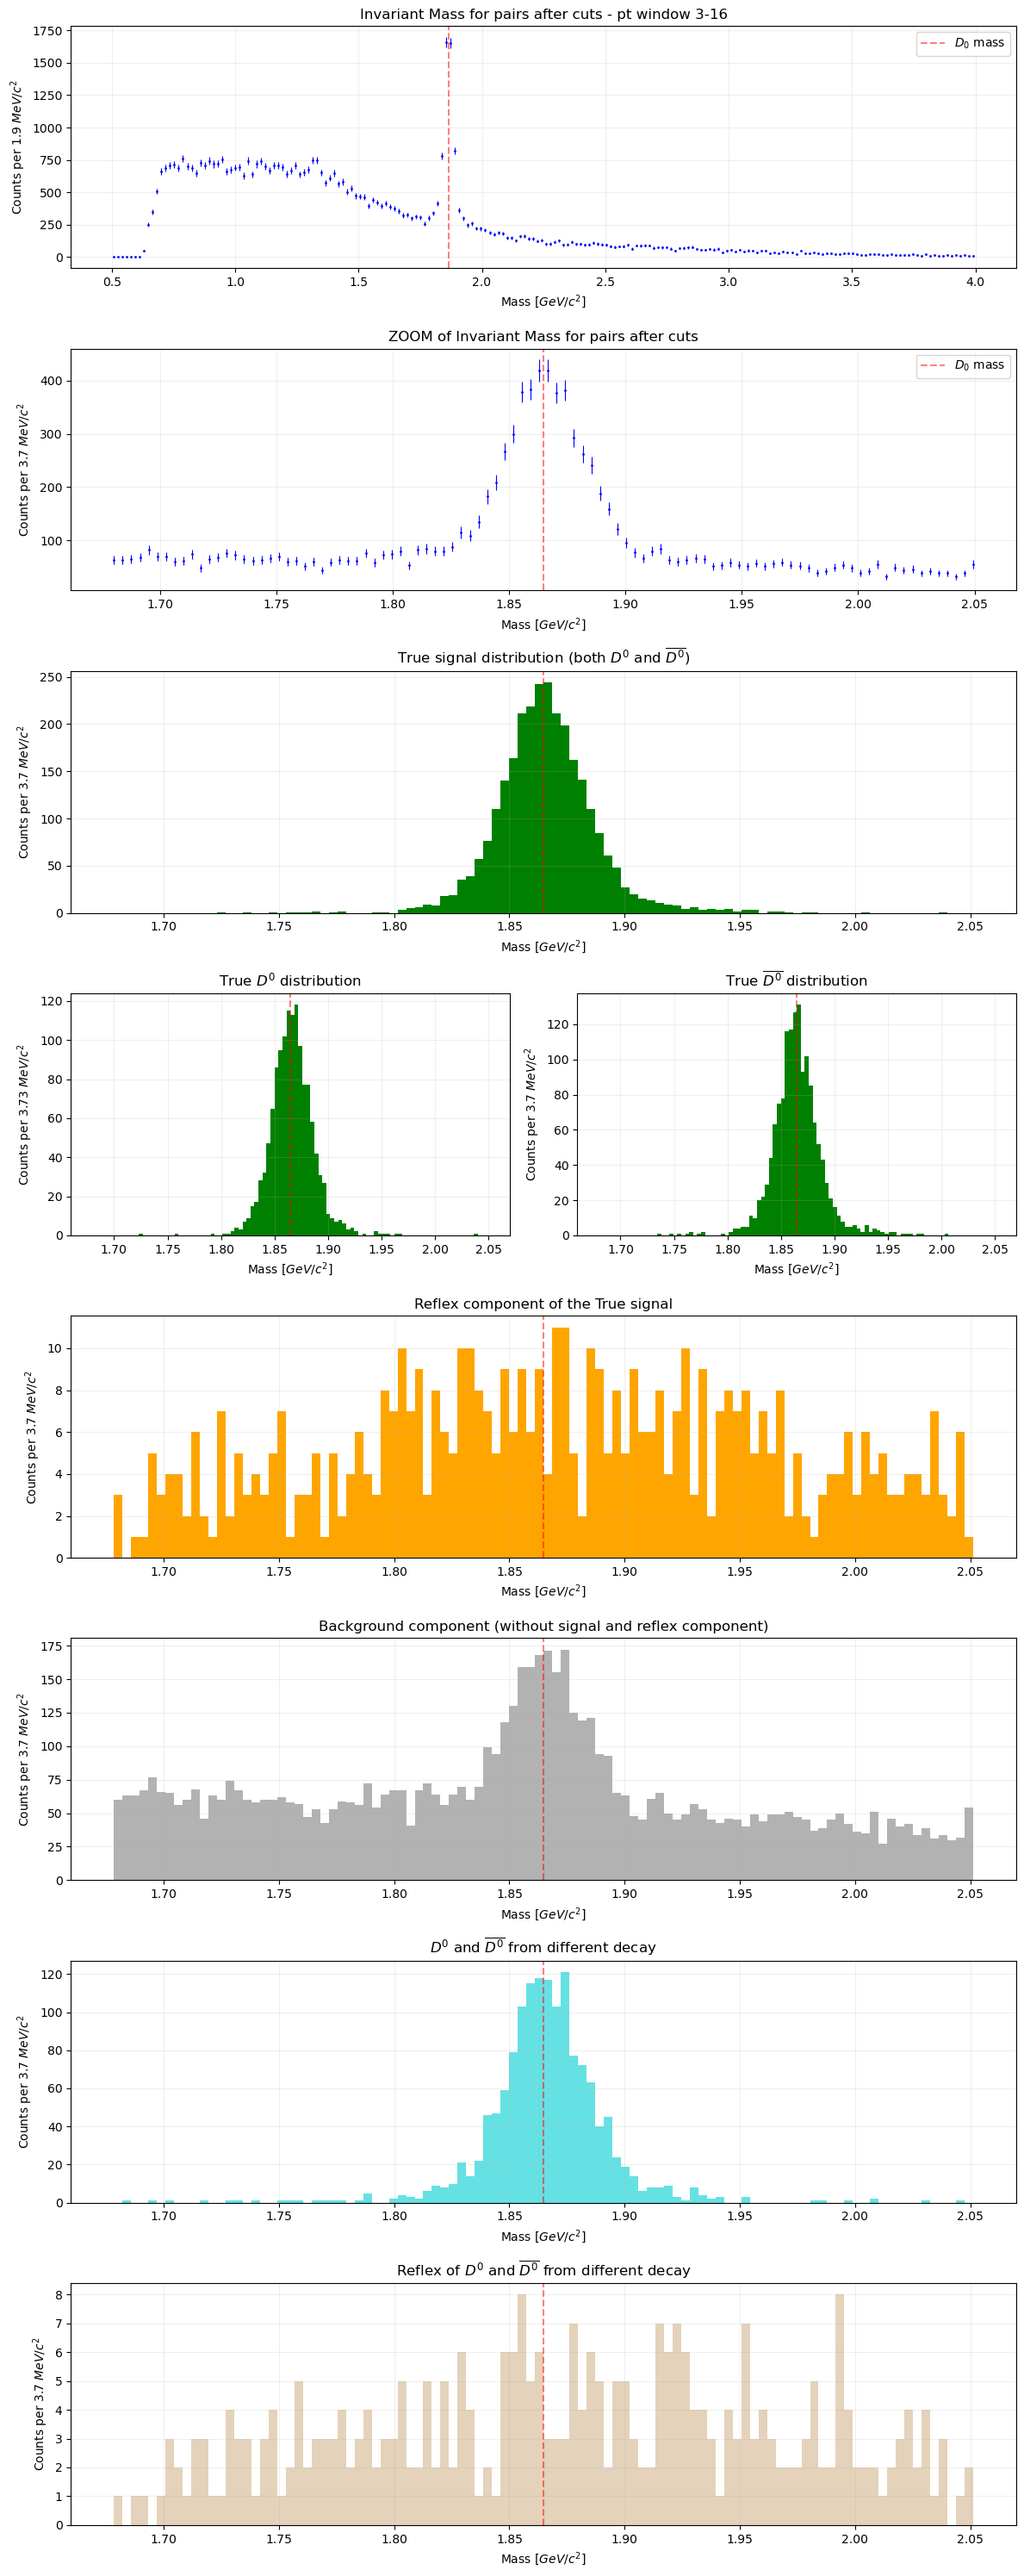

Let's confront signal before and after cuts + zoom in pt slice:

Total D0 before cuts:               11611
Total D0 found after cuts:          1333 ---> 11.48%

Total anti-D0 before cuts:          12159
Total anti-D0 found after cuts:     1448 ---> 11.91%

Total signal before cuts:           23770
Total signal found after cuts:      2781 ---> 11.70%

Total background found after cuts:  ---> 0.07%

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):

Signal found in the interval:     2655
Background found in the interval: 3460

Signal fraction in interval:     43.42%
Significance (S/√(S+B)):          33.95
Ratio (S/B):                      0.77


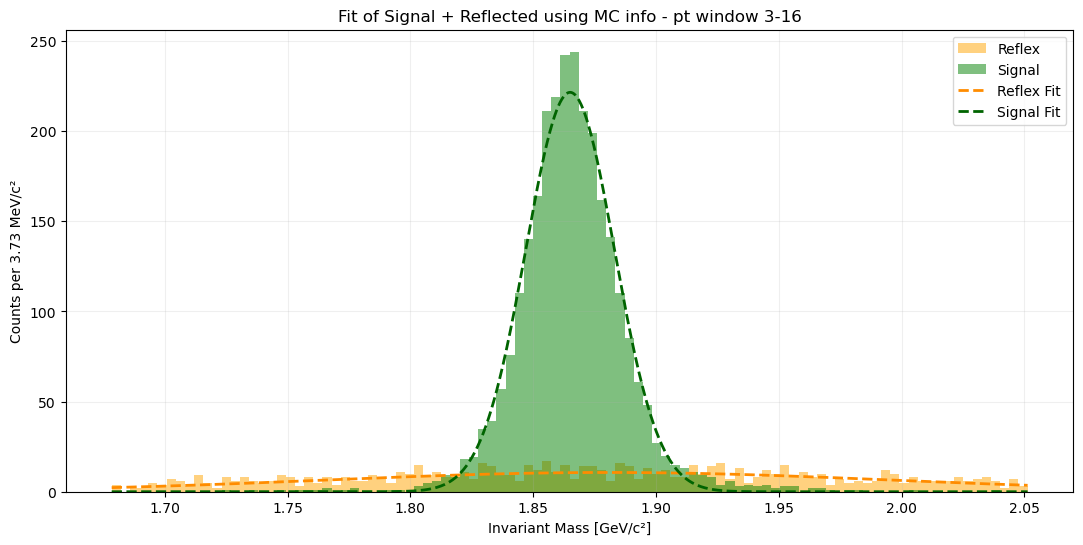


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8650       0.0180       10.018
Reflex             1.8808       0.1152        3.084 

Ratio N1/N2 (reflex/signal):                  0.308 


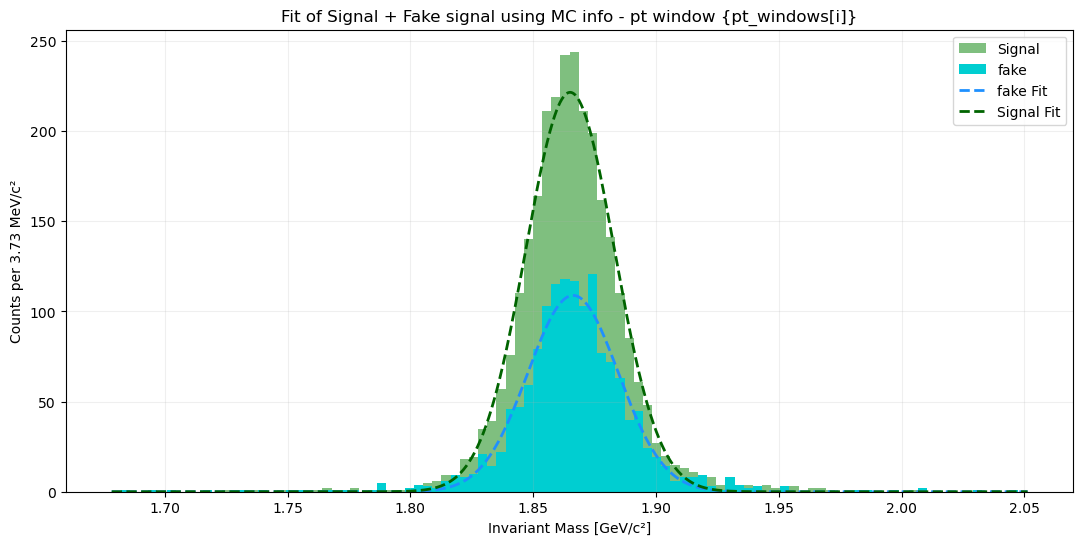


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8650       0.0180       10.018
fake               1.8662       0.0184        5.022 

Ratio N3/N2 (fake/signal):                  0.501 


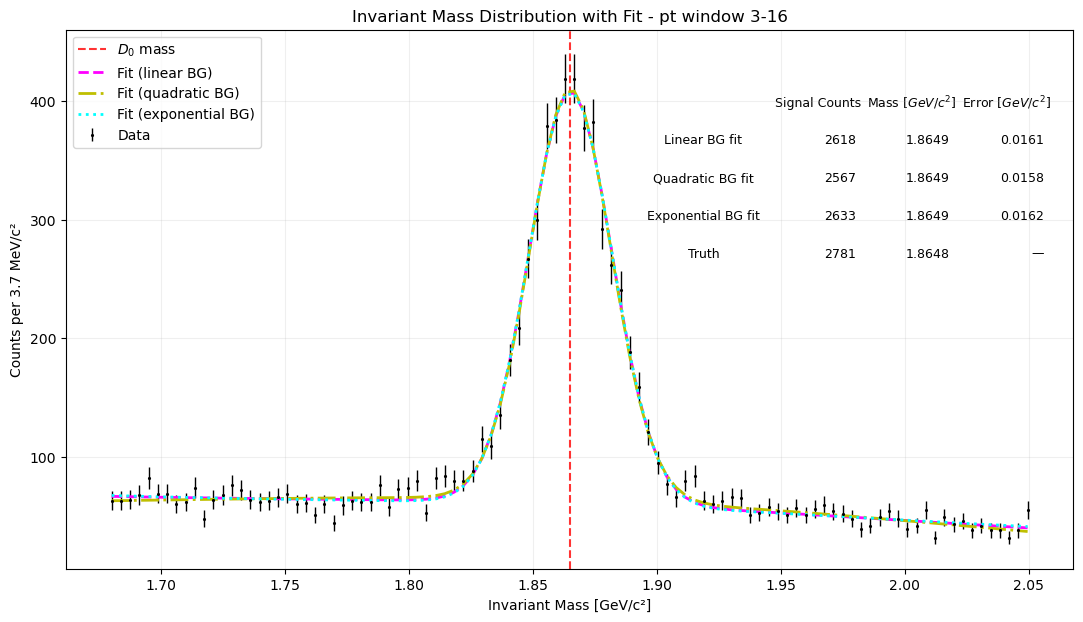


================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear             2618     1.864866     0.016117
Quadratic          2567     1.864865     0.015753
Exponential        2633     1.864855     0.016227
truth              2781     1.864840


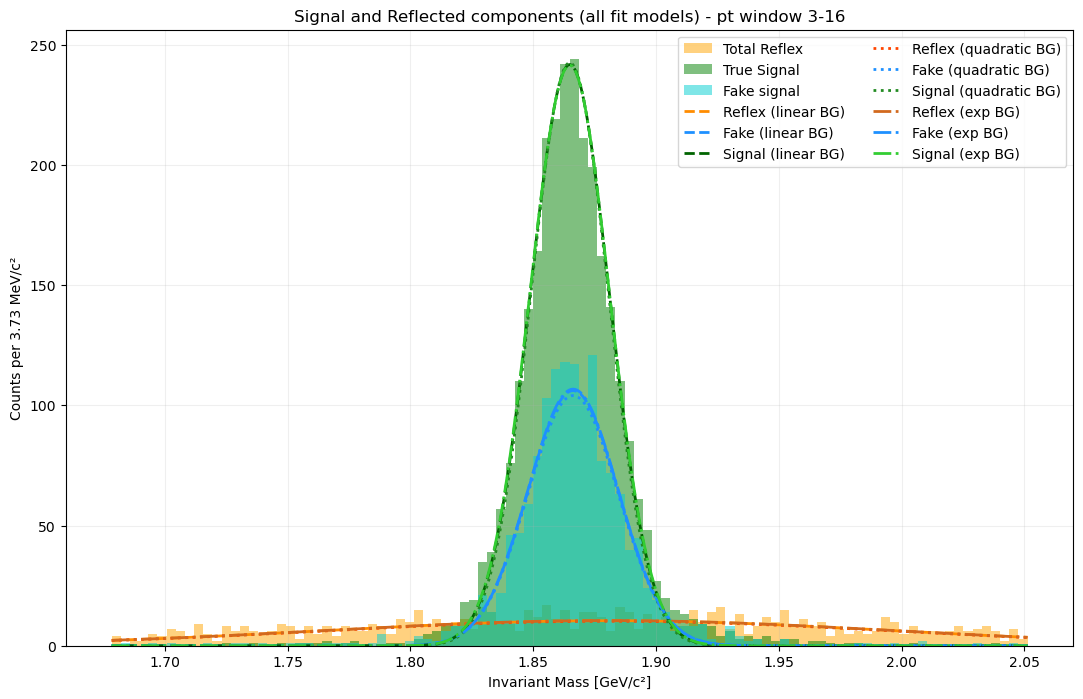

In [16]:
for i, mask_pt in enumerate(multiple_masks_pt):

    df = final_results.loc[ mask_pt ]
    print(f"======== STATISTICS FOR PAIR DATAFRAME of the pT window {pt_windows[i]} ========= \n")
    
    print(f"Length of dataframe: {len(df):_} rows\n")
    
    # MOTHER HYPOTHESIS
    mask_d0_hyp         = (df["mother_hyp"] == "D0")
    mask_anti_d0_hyp    = (df["mother_hyp"] == "Anti-D0")
    mask_both_hyp       = (df["mother_hyp"] == "BothSignal")
    d0_hyp_tot       =   mask_d0_hyp.sum()
    anti_d0_hyp_tot  =   mask_anti_d0_hyp.sum()
    both_hyp_tot     =   mask_both_hyp.sum()
    print("MOTHER HYPOTHESIS COUNTS:")
    print(f"Number of hypothetic D0:               {d0_hyp_tot:_}")
    print(f"Number of hypothetic Anti-D0:          {anti_d0_hyp_tot:_}")
    print(f"Number of double hypothesis particles: {both_hyp_tot:_}")
    print(f"Total hypothetic signal:               {d0_hyp_tot + anti_d0_hyp_tot + 2*both_hyp_tot:_} \n")
    
    # ---------- let's redefine the masks for the MC info on TRUE D0 and anti-D0 ------
    # I count the D0 that are either true D0 in D0 hypotheses or true D0 in 'both' hypotheses
    mask_true_d0_cutted_pt = ( mask_d0_hyp | mask_both_hyp ) & ( df["truth"] == 1 )
    # I count the anti-D0 that are either true anti-D0 in anti-D0 hypotheses or true anti-D0 in 'both' hypotheses
    mask_true_anti_d0_cutted_pt = ( mask_anti_d0_hyp | mask_both_hyp ) & ( df["truth"] == -1 )
    mask_signal_cutted_pt = ( (mask_true_d0_cutted_pt) | (mask_true_anti_d0_cutted_pt) )
    mask_background_cutted_pt = ( ~mask_signal_cutted_pt )
    
    d0_tot_cutted_pt = np.sum( mask_true_d0_cutted_pt )
    anti_d0_tot_cutted_pt = np.sum( mask_true_anti_d0_cutted_pt )
    signal_tot_cutted_pt = d0_tot_cutted_pt + anti_d0_tot_cutted_pt
    num_bg_pairs_cutted_pt = np.sum( mask_background_cutted_pt )
    print("TRUE SIGNAL COUNTS:")
    print("Number of D0:      ", d0_tot_cutted_pt )
    print("Number of anti-D0: ", anti_d0_tot_cutted_pt )
    print(f"Number of signal particles: ", signal_tot_cutted_pt )
    print(f"Number of background pairs: {num_bg_pairs_cutted_pt:_}")
    print(f"Fraction of signal over total: {(d0_tot_cutted_pt+anti_d0_tot_cutted_pt)/len(df) * 100:.4f}%"  )



    # ========================================== REFLEX COMPONENT ==========================================
    # reflex component given by true D0 classified as anti-D0 hyp (and so we kept its anti-mass)
    mask_reflex_from_anti_D0_hyp = mask_anti_d0_hyp & ( df["truth"] == 1 )
    mass_reflex_from_anti_D0_hyp = df.loc[ mask_reflex_from_anti_D0_hyp, "anti_mass"].values
    
    # reflex component given by true anti-D0 classified as D0 hyp (and so we kept its mass)
    mask_reflex_from_D0_hyp = mask_d0_hyp & ( df["truth"] == -1 )
    mass_reflex_from_D0_hyp =      df.loc[ mask_reflex_from_D0_hyp, "inv_mass"].values
    
    # now the reflex component coming by the wrong mass in the 'both' hypothesis
    mass_reflex_from_both_hyp = np.concatenate([ 
        df.loc[ mask_both_hyp & ( df["truth"] == 1 ), "anti_mass"].values,
        df.loc[ mask_both_hyp & ( df["truth"] == -1 ), "inv_mass"].values
    ])
    
    reflex_data = np.concatenate([ 
        mass_reflex_from_anti_D0_hyp,
        mass_reflex_from_D0_hyp,
        mass_reflex_from_both_hyp
    ])
    print("TRUE D0 CLASSIFICATION:")
    
    n_d0_as_d0 = np.sum( (df["truth"] == 1) & mask_d0_hyp )
    n_d0_as_anti = np.sum( (df["truth"] == 1) & mask_anti_d0_hyp )
    n_d0_as_both = np.sum( (df["truth"] == 1) & mask_both_hyp )
    
    print(f"Number of D0 classified as D0:       {n_d0_as_d0:_}")
    print(f"Number of D0 classified as anti-D0:  {n_d0_as_anti:_}  (these are not kept in our true masks)")
    print(f"Number of D0 classified as 'both':   {n_d0_as_both:_}\n")
    
    print("TRUE ANTI-D0 CLASSIFICATION:")
    
    n_anti_as_d0 = np.sum( (df["truth"] == -1) & mask_d0_hyp )
    n_anti_as_anti = np.sum( (df["truth"] == -1) & mask_anti_d0_hyp )
    n_anti_as_both = np.sum( (df["truth"] == -1) & mask_both_hyp )
    
    print(f"Number of anti-D0 classified as D0:       {n_anti_as_d0:_} (these are not kept in our true masks)")
    print(f"Number of anti-D0 classified as anti-D0:  {n_anti_as_anti:_}")
    print(f"Number of anti-D0 classified as 'both':   {n_anti_as_both:_}\n")
    
    print("REFLEX CLASSIFICATION:")
    
    print(f"Number of reflex by wrong classified D0:        {len(mass_reflex_from_anti_D0_hyp)}" )
    print(f"Number of reflex by wrong classified anti-D0:   {len(mass_reflex_from_D0_hyp)}")
    print(f"Number of reflex by wrong classified in 'both': {len(mass_reflex_from_both_hyp)}")
    print(f"Total reflex component: {len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp)} particles")



    # ========================================== DATA COMPONENT ==========================================
    # LET'S RETRIEVE THE MASS DATA:
    
    # --- invariant mass selection based on mother hypothesis -----------------
    mass_data_d0_hyp         = df.loc[mask_d0_hyp,     "inv_mass"].values
    mass_data_anti_d0_hyp    = df.loc[mask_anti_d0_hyp, "anti_mass"].values
    
    mass_data_both_hyp_inv   = df.loc[mask_both_hyp,   "inv_mass"].values
    mass_data_both_hyp_anti  = df.loc[mask_both_hyp,   "anti_mass"].values
    
    mass_data_hyp = np.concatenate([
        mass_data_d0_hyp,
        mass_data_anti_d0_hyp,
        mass_data_both_hyp_inv,
        mass_data_both_hyp_anti
    ])
    print(f"We have {len(mass_data_hyp)} data particles")
    
    # --- true signal mass data -------------------------------
    mass_data_true_d0         = df.loc[ mask_true_d0_cutted_pt, "inv_mass"].values
    mass_data_true_anti_d0    = df.loc[ mask_true_anti_d0_cutted_pt, "anti_mass"].values
    mass_true_signal = np.concatenate([ mass_data_true_d0, mass_data_true_anti_d0 ])
    
    print(f"We have {len(mass_true_signal)} signal particles")



    # ========================================== BG COMPONENT ==========================================
    # ----------------------- BACKGROUND MASS DATA -------------------------
    mask_bg_d0_hyp        = mask_d0_hyp & (df["truth"] == 0)
    mask_bg_anti_d0_hyp   = mask_anti_d0_hyp & (df["truth"] == 0)
    mask_bg_both_hyp      = mask_both_hyp & (df["truth"] == 0)
    
    mass_bg_d0_hyp       = df.loc[mask_bg_d0_hyp, "inv_mass"].values
    mass_bg_anti_d0_hyp  = df.loc[mask_bg_anti_d0_hyp, "anti_mass"].values
    mass_bg_both_hyp     = np.concatenate([
        df.loc[mask_bg_both_hyp, "inv_mass"].values,
        df.loc[mask_bg_both_hyp, "anti_mass"].values
    ])
    
    mass_bg_all = np.concatenate([mass_bg_d0_hyp, mass_bg_anti_d0_hyp, mass_bg_both_hyp])
    
    print(f"We have {len(mass_bg_all)} bg particles (withoud reflex component)")
    
    print(f"So in the end we have:\n")
    print(f"{len(mass_true_signal)} singal part.  +  "
        f"{len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp)} reflex part.  +  "
        f"{len(mass_bg_all)} bg particles = {len(mass_true_signal) +len(mass_reflex_from_anti_D0_hyp) + len(mass_reflex_from_D0_hyp) + len(mass_reflex_from_both_hyp) + len(mass_bg_all) } total particles. \n"
        f"that should be equal to the counted {len(mass_data_hyp)} data particles\n"
    )
    
    # ------------------------------------------------------------------
    # BACKGROUND D0 FROM OTHER DECAYS:
    mask_fake_D0_hyp = mask_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
    mask_fake_anti_D0_hyp = mask_anti_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
    mask_fake_D0_both_hyp = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
    mask_fake_anti_D0_both_hyp = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
    
    mass_fake_d0_hyp       = df.loc[mask_fake_D0_hyp, "inv_mass"].values
    mass_fake_anti_d0_hyp  = df.loc[mask_fake_anti_D0_hyp, "anti_mass"].values
    mass_fake_both_hyp     = np.concatenate([
        df.loc[mask_fake_D0_both_hyp, "inv_mass"].values,
        df.loc[mask_fake_anti_D0_both_hyp, "anti_mass"].values
    ])
    
    mass_fake_signal = np.concatenate([mass_fake_d0_hyp, mass_fake_anti_d0_hyp, mass_fake_both_hyp])
    print(f"We have {len(mass_fake_signal)} bg particles that are D0 or anti-D0 from different decays (withoud reflex component)\n")
    
    # ------------------------------------------------------------------
    # BACKGROUND REFLEX D0 FROM OTHER DECAYS:
    aaa = mask_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
    bbb = mask_anti_d0_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
    ccc = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == 421) & df["same_mother"]
    ddd = mask_both_hyp & (df["truth"] == 0) & ( df["mother_pdg_pos"] == -421) & df["same_mother"]
    
    eee       = df.loc[aaa, "inv_mass"].values
    fff  = df.loc[bbb, "anti_mass"].values
    ggg     = np.concatenate([
        df.loc[ccc, "anti_mass"].values,
        df.loc[ddd, "inv_mass"].values
    ])
    
    mass_fake_reflex = np.concatenate([eee, fff, ggg])
    print(f"We have {len(mass_fake_reflex)} bg particles that are D0 or anti-D0 from different decays (without reflex component)")
    
    
    

    # ======================================== INCVARIANT MASS PLOT ==========================================
    MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0     # for zoom
    N_BINS = 100
    
    # Layout con due colonne
    zones = [
        ["total", "total"],
        ["total_zoom", "total_zoom"],
        ["signal", "signal"],           # both D0 and anti_D0
        ["D0", "anti_D0"],
        ["reflex", "reflex"],
        ["BG","BG"],
        ["fake_signal", "fake_signal"],
        ["fake_reflex", "fake_reflex"]
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axs = plt.subplot_mosaic(
        zones,
        figsize=(12, 30),
        gridspec_kw={"width_ratios": [1, 1]}
    )
    
    # ----------------------- DATA PLOT -----------------------------------------------
    # PLOT OF ALL PAIRS
    counts, bin_edges = np.histogram(mass_data_hyp, bins=2*N_BINS, range=(0.5, 4))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(counts)         # poisson errors
    axs["total"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue', elinewidth=0.8)
    axs["total"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
    axs["total"].set_xlabel("Mass [$GeV/c^2$]")
    axs["total"].set_ylabel(f"Counts per {( (MAX_MASS-MIN_MASS)/(2*N_BINS) )*1000:.1f} $MeV/c^2$")
    axs["total"].set_title(f"Invariant Mass for pairs after cuts - pt window {pt_windows[i]}")
    axs["total"].set_xticks( np.arange(0.5, 4.1, 0.5) )
    axs["total"].legend()
    axs["total"].grid(alpha=0.2)
    
    # ZOOM OF ALL PAIRS
    counts, bin_edges = np.histogram(mass_data_hyp, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(counts)         # poisson errors
    axs["total_zoom"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue', elinewidth=0.8)
    axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
    axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
    axs["total_zoom"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["total_zoom"].set_title("ZOOM of Invariant Mass for pairs after cuts")
    #axs["total_zoom"].set_xticks( np.arange(1.5, 2.2, 0.05) )
    axs["total_zoom"].legend()
    axs["total_zoom"].grid(alpha=0.2)
    
    # -------------------------- TRUE SIGNAL MC -------------------------------------------------
    # TRUE SIGNAL
    axs["signal"].hist( mass_true_signal, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='green')
    axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
    axs["signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["signal"].set_title("True signal distribution (both $D^0$ and $\overline{{D^0}}$)")
    axs["signal"].grid(alpha=0.2)
    
    # only D0
    axs["D0"].hist( mass_data_true_d0, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='green')
    axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
    axs["D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
    axs["D0"].set_title("True $D^0$ distribution")
    axs["D0"].grid(alpha=0.2)
    
    # only anti_D0
    axs["anti_D0"].hist( mass_data_true_anti_d0, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='green')
    axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
    axs["anti_D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["anti_D0"].set_title("True $\overline{{D^0}}$ distribution")
    axs["anti_D0"].grid(alpha=0.2)
    
    # ----------------------- REFLEX OF TRUE SIGNAL -----------------------------------------
    # reflex component of the true signal
    axs["reflex"].hist( reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='orange')
    axs["reflex"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["reflex"].set_xlabel("Mass [$GeV/c^2$]")
    axs["reflex"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["reflex"].set_title("Reflex component of the True signal")
    axs["reflex"].grid(alpha=0.2)
    
    # ----------------------------------- BG --------------------------------------------------
    axs["BG"].hist(mass_bg_all, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='gray', alpha=0.6)
    axs["BG"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["BG"].set_xlabel("Mass [$GeV/c^2$]")
    axs["BG"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["BG"].set_title("Background component (without signal and reflex component)")
    axs["BG"].grid(alpha=0.2)
    
    # ----------------------- D0 and anti-D0 from other decays ('FAKE SIGNAL') -------------------
    # plot of the D0 that does not come from our decay pi+ka
    axs["fake_signal"].hist(mass_fake_signal, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='darkturquoise', alpha=0.6)
    axs["fake_signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["fake_signal"].set_xlabel("Mass [$GeV/c^2$]")
    axs["fake_signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["fake_signal"].set_title("$D^0$ and $\overline{{D^0}}$ from different decay")
    axs["fake_signal"].grid(alpha=0.2)
    
    # --------------------------- REFLEX OF FAKE SIGNAL ----------------------------------------
    axs["fake_reflex"].hist(mass_fake_reflex, bins=N_BINS, range=(MIN_MASS, MAX_MASS), color='tan', alpha=0.6)
    axs["fake_reflex"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
    axs["fake_reflex"].set_xlabel("Mass [$GeV/c^2$]")
    axs["fake_reflex"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.1f} $MeV/c^2$")
    axs["fake_reflex"].set_title("Reflex of $D^0$ and $\overline{{D^0}}$ from different decay")
    axs["fake_reflex"].grid(alpha=0.2)
    
    
    #plt.savefig("D0_Mass_MC.png")
    plt.tight_layout()
    plt.show()





    # ======================================== INFO ON THE CUTS ==========================================
    print(f"Let's confront signal before and after cuts + zoom in pt slice:\n")
    print(f"Total D0 before cuts:               {d0_tot}")
    print(f"Total D0 found after cuts:          {d0_tot_cutted_pt} ---> {d0_tot_cutted_pt / d0_tot * 100:.2f}%\n")
    print(f"Total anti-D0 before cuts:          {anti_d0_tot}")
    print(f"Total anti-D0 found after cuts:     {anti_d0_tot_cutted_pt} ---> {anti_d0_tot_cutted_pt / anti_d0_tot * 100:.2f}%\n")
    print(f"Total signal before cuts:           {signal_tot}")
    print(f"Total signal found after cuts:      {signal_tot_cutted_pt} ---> {signal_tot_cutted_pt / signal_tot * 100:.2f}%\n")
    print(f"Total background found after cuts:  ---> {num_bg_pairs_cutted_pt / num_bg_pairs * 100:.2f}%\n" )
    
    print("LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL):\n")
    
    sigma_guess = 0.015
    mass_window = (m_d0 - 3*sigma_guess, m_d0 + 3*sigma_guess)
    
    # --- signal ---
    signal_in_window = mass_true_signal[(mass_true_signal > mass_window[0]) & (mass_true_signal < mass_window[1])]
    
    # --- background ---
    background = np.concatenate([
        df.loc[mask_background_cutted_pt, "inv_mass"].values,
        df.loc[mask_background_cutted_pt, "anti_mass"].values
    ])
    background_in_window = background[ (background > mass_window[0]) & (background < mass_window[1]) ]
    
    S = len(signal_in_window)
    B = len(background_in_window)
    
    print(
        f"Signal found in the interval:     {S}\n"
        f"Background found in the interval: {B}\n\n"
        f"Signal fraction in interval:     {S / (S + B) * 100:.2f}%\n"
        f"Significance (S/√(S+B)):          {S / np.sqrt(S + B):.2f}\n"
        f"Ratio (S/B):                      {S / B:.2f}"
    )
    
    
    
    
    # ======================================== INVARIANTE MASS FIT ==========================================
    reflex_data_tot = np.concatenate( [reflex_data, mass_fake_reflex] )



    # ======================================== FINDING RATIO N1/N2 ==========================================

    # --- Fit function: Gaussian---
    def fit_gauss_mc(x, k, mu1, sigma1):
        return k * norm.pdf(x, loc=mu1, scale=sigma1) 
    
    # INITIALIZATIONS:
    MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
    N_BINS = 100
    binsize = (MAX_MASS - MIN_MASS)/N_BINS
    # --- Initial parameter guesses ---
    k_param = 100
    gauss_params = [m_d0, 0.05]
    
    # ------------------------------------------------------------------
    # Histogram of TRUE signal and TRUE reflected components
    # signal:
    signal_data = mass_true_signal
    
    # HISTOGRAM:
    fig, ax = plt.subplots(figsize=(13,6))
    # ------- reflex component:
    reflex_counts, reflex_edges, _ = ax.hist(reflex_data_tot, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
    reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
    # poisson errors:
    sigma_reflex_hist = np.sqrt(reflex_counts)
    sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
    # ------- signal:
    sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
    sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
    # poisson errors:
    sigma_sign_hist = np.sqrt(sign_counts)
    sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros
    
    # FIT:
    sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                                p0 = [k_param, 
                                      gauss_params[0], gauss_params[1]
                                     ]
                            )
    sign_params = sign_fit_res[0]
    mu_sign, sigma_sign = sign_params[1], sign_params[2]
    k_sign = sign_params[0]
    # ----
    reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                                p0 = [k_param, 
                                      gauss_params[0], gauss_params[1]
                                     ]
                            )
    reflex_params = reflex_fit_res[0]
    mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
    k_reflex = reflex_params[0]
    
    # PLOT of fitted curves:
    x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')
    
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax.set_title(f"Fit of Signal + Reflected using MC info - pt window {pt_windows[i]}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()
    
    # PRINT:
    ratio_from_fit = k_reflex/k_sign
    print("\n================ FIT RESULTS =================")
    
    print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
    print("-"*48)
    print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
    print(f"{'Reflex':<12} {mu_reflex:>12.4f} {sigma_reflex:>12.4f} {k_reflex:>12.3f} \n")
    
    print(f"Ratio N1/N2 (reflex/signal):   {ratio_from_fit:>20.3f} ")





    # ======================================== FINDING RATIO N3/N2 ==========================================

    # --- Initial parameter guesses ---
    k_param = 100
    gauss_params = [m_d0, 0.05]
    
    # ------------------------------------------------------------------
    # Histogram of TRUE signal and TRUE reflected components
    
    # HISTOGRAM:
    fig, ax = plt.subplots(figsize=(13,6))
    # ------- signal:
    sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
    sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
    # poisson errors:
    sigma_sign_hist = np.sqrt(sign_counts)
    sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros
    # ------- fake component:
    fake_counts, fake_edges, _ = ax.hist(mass_fake_signal, bins=N_BINS, range=(MIN_MASS, MAX_MASS), label='fake', color='darkturquoise')
    fake_centers = (fake_edges[:-1] + fake_edges[1:]) / 2.0
    # poisson errors:
    sigma_fake_hist = np.sqrt(fake_counts)
    sigma_fake_hist = np.clip(sigma_fake_hist, 1, None)  # avoid zeros
    
    # FIT:
    
    # sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
    #                             p0 = [k_param, 
    #                                   gauss_params[0], gauss_params[1]
    #                                  ]
    #                         )
    # sign_params = sign_fit_res[0]
    # mu_sign, sigma_sign = sign_params[1], sign_params[2]
    # k_sign = sign_params[0]
    
    # ----
    fake_fit_res = curve_fit( fit_gauss_mc, xdata = fake_centers, ydata = fake_counts, sigma = sigma_fake_hist,
                                p0 = [k_param, 
                                      gauss_params[0], gauss_params[1]
                                     ]
                            )
    fake_params = fake_fit_res[0]
    mu_fake, sigma_fake = fake_params[1], fake_params[2]
    k_fake = fake_params[0]
    
    # PLOT of fitted curves:
    x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_fake, mu_fake, sigma_fake), '--', color='dodgerblue', linewidth=2, label='fake Fit')
    ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')
    
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax.set_title("Fit of Signal + Fake signal using MC info - pt window {pt_windows[i]}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()
    
    # PRINT:
    ratio_from_fit_2 = k_fake/k_sign
    print("\n================ FIT RESULTS =================")
    
    print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
    print("-"*48)
    print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
    print(f"{'fake':<12} {mu_fake:>12.4f} {sigma_fake:>12.4f} {k_fake:>12.3f} \n")
    
    print(f"Ratio N3/N2 (fake/signal):   {ratio_from_fit_2:>20.3f} ")





    # ======================================== FIT ==========================================













    # ======================== FIT FUNCTIONS ===============================
    
    # INITIALIZATIONS:
    MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
    N_BINS = 100
    binsize = (MAX_MASS - MIN_MASS)/N_BINS
    ratio = ratio_from_fit   # fixed ratio from previous fit N_reflex/N_signal
    ratio2 = ratio_from_fit_2
    
    # --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
    def fit_function_lin(x, k, mu1, sigma1, a, b):
        reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
        signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
        fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
        background   = a*x + b
        return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background
    
    # --- Fit function with quadratic background ---
    def fit_function_quad(x, k, mu1, sigma1, a2, a1, a0):
        reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
        signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
        fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
        background   = a2*x**2 + a1*x + a0
        return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background
    
    # --- Fit function with exponential background ---
    def fit_function_exp(x, k, mu1, sigma1, A, lamb):
        reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
        signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
        fake_part    = norm.pdf(x, loc=mu_fake,   scale=sigma_fake)
        background   = A * np.exp(lamb * x)
        return k * ( ratio*reflex_part + signal_part + ratio2*fake_part ) + background
    
    
    
    # ============================= DATA AND HISTOGRAM ==========================================
    
    mass_data_d0_hyp         = df.loc[mask_d0_hyp,     "inv_mass"].values
    mass_data_anti_d0_hyp    = df.loc[mask_anti_d0_hyp, "anti_mass"].values
    
    mass_data_both_hyp_inv   = df.loc[mask_both_hyp,   "inv_mass"].values
    mass_data_both_hyp_anti  = df.loc[mask_both_hyp,   "anti_mass"].values
    
    data = np.concatenate([
        mass_data_d0_hyp,
        mass_data_anti_d0_hyp,
        mass_data_both_hyp_inv,
        mass_data_both_hyp_anti
    ])
    
    # HISTOGRAM:
    fig, ax = plt.subplots(figsize=(13,7))
    both_counts, both_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
    both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
    # --- Poisson errors ---
    sigma_hist = np.sqrt(both_counts)
    sigma_hist = np.clip(sigma_hist, 1, None)
    # plot:
    ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2.5, color='black', label='Data', elinewidth=1)
    ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.8)
    
    
    
    # =========================================== FIT =========================================
    
    # Initial parameter guesses
    k_param       = 100
    signal_params = [m_d0, 0.02]
    back_params   = [133, 1000]
    quad_back_params = [0.0, 0.0, 25]
    e = [14000, 750, 25]
    exp_back_params  = [e[i], -0.01]  # as first value, put 25 for pt in [3-16], 750 in [1.5-3], 14000 for [0-1.5]
    
    # LINEAR FIT:
    both_fit_res = curve_fit(
        f       = fit_function_lin,
        xdata   = both_centers,
        ydata   = both_counts,
        sigma   = sigma_hist,
        p0      = [
            k_param,                # 0: k
            signal_params[0],       # 1: mu1
            signal_params[1],       # 2: sigma1
            back_params[0],         # 3: a
            back_params[1]          # 4: b
        ]
    )
    both_params = both_fit_res[0]
    # k_fit, mu1, sigma1, a_fit, b_fit = both_params
    
    # QUADRATIC FIT:
    quad_fit_res = curve_fit(
        f       = fit_function_quad,
        xdata   = both_centers,
        ydata   = both_counts,
        sigma   = sigma_hist,
        p0      = [
            k_param,
            signal_params[0],
            signal_params[1],
            *quad_back_params
        ]
    )
    quad_params = quad_fit_res[0]
    
    # EXPONENTIAL FIT:
    exp_fit_res = curve_fit(
        f       = fit_function_exp,
        xdata   = both_centers,
        ydata   = both_counts,
        sigma   = sigma_hist,
        p0      = [
            k_param,
            signal_params[0],
            signal_params[1],
            *exp_back_params
        ]
    )
    exp_params = exp_fit_res[0]
    
    
    # =================== PLOT FITTED CURVES ========================================
    
    # --- Plot fitted curves ---
    ax.plot( both_centers, fit_function_lin(both_centers, *both_params),
             color='magenta', linestyle='dashed', linewidth=2., label='Fit (linear BG)'
    )
    
    ax.plot( both_centers, fit_function_quad(both_centers, *quad_params),
             color='y', linestyle='dashdot', linewidth=2, label='Fit (quadratic BG)'
    )
    
    ax.plot( both_centers, fit_function_exp(both_centers, *exp_params),
             color='cyan', linestyle='dotted', linewidth=2, label='Fit (exponential BG)'
    )
    
    
    # ==================== RESULTS ===============================================
    
    def signal_yield_from_fit(k, mu, sigma, binsize, xmin, xmax):
        integral = norm.cdf(xmax, mu, sigma) - norm.cdf(xmin, mu, sigma)
        return (k * integral) / binsize
        
    k_lin, mu_lin, sigma_lin, *_ = both_params
    N_sig_lin = signal_yield_from_fit( k_lin, mu_lin, sigma_lin, binsize, MIN_MASS, MAX_MASS )
    
    k_quad, mu_quad, sigma_quad, *_ = quad_params
    N_sig_quad = signal_yield_from_fit( k_quad, mu_quad, sigma_quad, binsize, MIN_MASS, MAX_MASS )
    
    k_exp, mu_exp, sigma_exp, *_ = exp_params
    N_sig_exp = signal_yield_from_fit( k_exp, mu_exp, sigma_exp, binsize, MIN_MASS, MAX_MASS )
    
    
    # # TABLE INSIDE PLOT:
    # ax.table(
    #     cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    #     rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    #     colLabels = ['Signal'],
    #     colLoc = "right",
    #     bbox = [0.75, 0.8, 0.25, 0.2],
    #     edges = 'open',
    #     rowLoc = 'right'
    # )
    
    # ======================= TABLE INSIDE PLOT =======================
    
    cell_text = [
        [f"{N_sig_lin:.0f}",  f"{mu_lin:.4f}",  f"{sigma_lin:.4f}"],
        [f"{N_sig_quad:.0f}", f"{mu_quad:.4f}", f"{sigma_quad:.4f}"],
        [f"{N_sig_exp:.0f}",  f"{mu_exp:.4f}",  f"{sigma_exp:.4f}"],
        [f"{len(mass_true_signal)}",       f"{m_d0:.4f}",    "—"]
    ]
    
    row_labels = [
        "Linear BG fit",
        "Quadratic BG fit",
        "Exponential BG fit",
        "Truth"
    ]
    
    col_labels = [
        r"Signal Counts",
        r"Mass [$GeV/c^2$]",
        r"Error [$GeV/c^2$]"
    ]
    
    table = ax.table(
        cellText   = cell_text,
        rowLabels  = row_labels,
        colLabels  = col_labels,
        colLoc     = "center",
        rowLoc     = "center",
        bbox       = [0.70, 0.55, 0.28, 0.35],     # bbox = [x0, y0, width, height] in axes coordinates (0–1)
        edges      = "open"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.1f} MeV/c²")
    ax.set_title(f"Invariant Mass Distribution with Fit - pt window {pt_windows[i]}")
    ax.legend(loc='upper left')
    ax.grid(alpha=0.2)
    plt.show()
    
    
    # ================================ PRINT RESULTS ==========================================
    
    print("\n================ FIT RESULTS =================")
    
    print(f"{'Fit':<12} {'N_signal':>10} {'mu':>12} {'sigma':>12}")
    print("-"*48)
    print(f"{'Linear':<12} {N_sig_lin:>10.0f} {mu_lin:>12.6f} {sigma_lin:>12.6f}")
    print(f"{'Quadratic':<12} {N_sig_quad:>10.0f} {mu_quad:>12.6f} {sigma_quad:>12.6f}")
    print(f"{'Exponential':<12} {N_sig_exp:>10.0f} {mu_exp:>12.6f} {sigma_exp:>12.6f}")
    print(f"{'truth':<12} {len(mass_true_signal):>10.0f} {m_d0:>12.6f}")





















 # ========================= OVERLAYING OUR FIT WITH TRUE MC DATA =========================



    fig, ax = plt.subplots(figsize=(13, 8))
    
    # ===================== DATA =====================
    # already defines reflex_data_tot and signal_data
    
    # ===================== HISTOGRAMS =====================
    
    ax.hist( reflex_data_tot, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='orange', alpha=0.5, label='Total Reflex' )
    
    ax.hist( signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='green', alpha=0.5, label='True Signal' )
    
    ax.hist( mass_fake_signal, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='darkturquoise', alpha=0.5, label='Fake signal' )
    
    # ===================== FITTED CURVES ===================
    
    x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
    
    # --- Linear BG fit ---
    ax.plot( x_fit, k_lin * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
        '--', color='darkorange', linewidth=2, label='Reflex (linear BG)' )
    
    ax.plot( x_fit, k_lin * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
        '--', color='dodgerblue', linewidth=2, label='Fake (linear BG)' )
    
    ax.plot( x_fit, k_lin * norm.pdf(x_fit, mu_lin, sigma_lin),
        '--', color='darkgreen', linewidth=2, label='Signal (linear BG)' )
    
    # --- Quadratic BG fit ---
    ax.plot( x_fit, k_quad * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
        ':', color='orangered', linewidth=2, label='Reflex (quadratic BG)' )
    
    ax.plot( x_fit, k_quad * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
        ':', color='dodgerblue', linewidth=2, label='Fake (quadratic BG)' )
    
    ax.plot( x_fit, k_quad * norm.pdf(x_fit, mu_quad, sigma_quad),
        ':', color='forestgreen', linewidth=2, label='Signal (quadratic BG)' )
    
    # --- Exponential BG fit ---
    ax.plot( x_fit, k_exp * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
        '-.', color='chocolate', linewidth=2, label='Reflex (exp BG)' )
    
    ax.plot( x_fit, k_exp * ratio2 * norm.pdf(x_fit, mu_fake, sigma_fake),
        '-.', color='dodgerblue', linewidth=2, label='Fake (exp BG)' )
    
    ax.plot( x_fit, k_exp * norm.pdf(x_fit, mu_exp, sigma_exp),
        '-.', color='limegreen', linewidth=2, label='Signal (exp BG)' )
    
    # ===================== STYLE =====================
    
    ax.set_xlabel("Invariant Mass [GeV/c²]")
    ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
    ax.set_title(f"Signal and Reflected components (all fit models) - pt window {pt_windows[i]}")
    ax.legend(ncol=2, fontsize=10)
    ax.grid(alpha=0.2)
    
    #plt.tight_layout()
    plt.show()


#### RESULTS FOR pT window [3-16]
```
================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear             2618     1.864866     0.016117
Quadratic          2567     1.864865     0.015753
Exponential        2633     1.864855     0.016227
truth              2781     1.864840
```
#### RESULTS FOR pT window [1.5-3]
```
================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear             2888     1.865541     0.012603
Quadratic          3028     1.865598     0.013160
Exponential        3027     1.865582     0.013156
truth              3195     1.864840
```
#### RESULTS FOR pT window [0-1.5]
```
================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear            -4568     1.928662     0.021319
Quadratic          3946     1.866909     0.012090
Exponential        9352     1.799281     0.110851
truth              4064     1.864840
```